In [151]:
# import os
# import zipfile
# import gdown

# # 1. Configuration
# GOOGLE_DRIVE_FILE_ID = "1JAqHtTKaZrV64L2-z6M2DY9XA5PSEP8K"
# ZIP_FILE_NAME = "Gaming_Profiles_Data.zip"
# EXTRACT_FOLDER = "Gaming_Profiles_Data"

# # 2. Check if the dataset already exists locally
# if not os.path.exists(EXTRACT_FOLDER):
#     print(f"'{EXTRACT_FOLDER}' not found. Initiating download from Google Drive...")
    
#     # Construct the direct download URL
#     url = f"https://google.com{GOOGLE_DRIVE_FILE_ID}"
    
#     # Download the zip file
#     gdown.download(url, ZIP_FILE_NAME, quiet=False)
    
#     # Extract the zip file
#     print("Extracting files... This may take a moment.")
#     with zipfile.ZipFile(ZIP_FILE_NAME, 'r') as zip_ref:
#         zip_ref.extractall(".")
        
#     # Clean up the zip file to save local storage space
#     os.remove(ZIP_FILE_NAME)
#     print("Setup complete! Data is ready to use.")
# else:
#     print(f"'{EXTRACT_FOLDER}' already exists locally. Skipping download.")


In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests as req 
import ast 
import sqlite3

In [153]:
df = pd.read_csv(r'..\Gaming_Mental_Health_Data\Gaming and Mental Health.csv')
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [154]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   str    
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   str    
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   str    
 5   primary_game                      1000 non-null   str    
 6   gaming_platform                   1000 non-null   str    
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   str    
 9   sleep_disruption_frequency        1000 non-null   str    
 10  academic_work_performance         1000 non-null   str    
 11  grades_gpa                        754 non-null    float64
 12  work_productivity_

In [155]:
df.shape

(1000, 27)

In [156]:
df.value_counts()

record_id  age  gender  daily_gaming_hours  game_genre     primary_game       gaming_platform  sleep_hours  sleep_quality  sleep_disruption_frequency  academic_work_performance  grades_gpa  work_productivity_score  mood_state  mood_swing_frequency  withdrawal_symptoms  loss_of_other_interests  continued_despite_problems  eye_strain  back_neck_pain  weight_change_kg  exercise_hours_weekly  social_isolation_score  face_to_face_social_hours_weekly  monthly_game_spending_usd  years_gaming  gaming_addiction_risk_level
GD0002     21   Male    3.0                 MOBA           Dota 2             PC               7.2          Fair           Rarely                      Good                       3.75        2.0                      Irritable   Often                 False                False                    False                       False       False           0.4               8.5                    2                       10.7                              46.64                      1   

In [157]:
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


In [158]:
df.isnull().sum()

record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_usd             0


In [159]:
df.isna()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [160]:
mystery_rows = df[df['grades_gpa'].isnull() & df['work_productivity_score'].isnull()]
print(f"Number of users with no school or work data: {len(mystery_rows)}")


Number of users with no school or work data: 0


In [161]:
# Create a clear 'Occupation' column
# If they have a GPA, they are a Student. Otherwise, they are a Professional.
df['Occupation'] = df['grades_gpa'].apply(lambda x: 'Student' if pd.notnull(x) else 'Professional')

# Double check the counts
print(df['Occupation'].value_counts())


Occupation
Student         754
Professional    246
Name: count, dtype: int64


In [162]:
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,Occupation
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,False,6.8,3.7,7,1.3,383.70,3,Severe,Student
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,0.4,8.5,2,10.7,46.64,1,Low,Student
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,False,True,1.8,7.1,5,3.2,100.81,6,Severe,Professional
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,True,True,0.2,5.2,4,9.1,51.60,7,High,Student
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,0.5,6.1,4,4.5,32.57,1,Moderate,Student


In [163]:
df.isnull().sum()

record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_usd             0


In [164]:
df = df.fillna("N/A")
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,Occupation
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,False,6.8,3.7,7,1.3,383.70,3,Severe,Student
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,0.4,8.5,2,10.7,46.64,1,Low,Student
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,False,True,1.8,7.1,5,3.2,100.81,6,Severe,Professional
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,True,True,0.2,5.2,4,9.1,51.60,7,High,Student
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,0.5,6.1,4,4.5,32.57,1,Moderate,Student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,1.9,7.5,6,2.4,426.54,3,Severe,Student
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,True,False,2.1,7.7,1,10.9,83.71,7,Low,Student
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,True,0.5,8.1,5,6.7,88.60,5,High,Professional
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,0.8,8.4,1,12.7,22.02,8,Low,Student


In [165]:
df.isnull().sum()

record_id                           0
age                                 0
gender                              0
daily_gaming_hours                  0
game_genre                          0
primary_game                        0
gaming_platform                     0
sleep_hours                         0
sleep_quality                       0
sleep_disruption_frequency          0
academic_work_performance           0
grades_gpa                          0
work_productivity_score             0
mood_state                          0
mood_swing_frequency                0
withdrawal_symptoms                 0
loss_of_other_interests             0
continued_despite_problems          0
eye_strain                          0
back_neck_pain                      0
weight_change_kg                    0
exercise_hours_weekly               0
social_isolation_score              0
face_to_face_social_hours_weekly    0
monthly_game_spending_usd           0
years_gaming                        0
gaming_addic

In [166]:
print(df[['grades_gpa', 'work_productivity_score', 'Occupation']].head(10))


  grades_gpa work_productivity_score    Occupation
0       1.25                     N/A       Student
1       3.75                     2.0       Student
2        N/A                     9.0  Professional
3       1.62                     2.0       Student
4       2.44                     N/A       Student
5       3.81                     4.0       Student
6       1.82                     6.0       Student
7        N/A                     1.0  Professional
8       2.43                     N/A       Student
9       1.13                     N/A       Student


In [167]:
df.dtypes

record_id                               str
age                                   int64
gender                                  str
daily_gaming_hours                  float64
game_genre                              str
primary_game                            str
gaming_platform                         str
sleep_hours                         float64
sleep_quality                           str
sleep_disruption_frequency              str
academic_work_performance               str
grades_gpa                           object
work_productivity_score              object
mood_state                              str
mood_swing_frequency                    str
withdrawal_symptoms                    bool
loss_of_other_interests                bool
continued_despite_problems             bool
eye_strain                             bool
back_neck_pain                         bool
weight_change_kg                    float64
exercise_hours_weekly               float64
social_isolation_score          

In [168]:
df['grades_gpa'] = pd.to_numeric(df['grades_gpa'], errors='coerce')
df


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,Occupation
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,False,6.8,3.7,7,1.3,383.70,3,Severe,Student
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,0.4,8.5,2,10.7,46.64,1,Low,Student
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,False,True,1.8,7.1,5,3.2,100.81,6,Severe,Professional
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,True,True,0.2,5.2,4,9.1,51.60,7,High,Student
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,0.5,6.1,4,4.5,32.57,1,Moderate,Student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,1.9,7.5,6,2.4,426.54,3,Severe,Student
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,True,False,2.1,7.7,1,10.9,83.71,7,Low,Student
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,True,0.5,8.1,5,6.7,88.60,5,High,Professional
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,0.8,8.4,1,12.7,22.02,8,Low,Student


In [169]:
df['work_productivity_score'] = pd.to_numeric(df['work_productivity_score'], errors='coerce')
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,Occupation
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,False,6.8,3.7,7,1.3,383.70,3,Severe,Student
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,0.4,8.5,2,10.7,46.64,1,Low,Student
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,False,True,1.8,7.1,5,3.2,100.81,6,Severe,Professional
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,True,True,0.2,5.2,4,9.1,51.60,7,High,Student
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,0.5,6.1,4,4.5,32.57,1,Moderate,Student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,1.9,7.5,6,2.4,426.54,3,Severe,Student
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,True,False,2.1,7.7,1,10.9,83.71,7,Low,Student
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,True,0.5,8.1,5,6.7,88.60,5,High,Professional
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,0.8,8.4,1,12.7,22.02,8,Low,Student


In [170]:
df.dtypes

record_id                               str
age                                   int64
gender                                  str
daily_gaming_hours                  float64
game_genre                              str
primary_game                            str
gaming_platform                         str
sleep_hours                         float64
sleep_quality                           str
sleep_disruption_frequency              str
academic_work_performance               str
grades_gpa                          float64
work_productivity_score             float64
mood_state                              str
mood_swing_frequency                    str
withdrawal_symptoms                    bool
loss_of_other_interests                bool
continued_despite_problems             bool
eye_strain                             bool
back_neck_pain                         bool
weight_change_kg                    float64
exercise_hours_weekly               float64
social_isolation_score          

In [171]:
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,Occupation
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,False,6.8,3.7,7,1.3,383.70,3,Severe,Student
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,0.4,8.5,2,10.7,46.64,1,Low,Student
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,False,True,1.8,7.1,5,3.2,100.81,6,Severe,Professional
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,True,True,0.2,5.2,4,9.1,51.60,7,High,Student
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,0.5,6.1,4,4.5,32.57,1,Moderate,Student


In [172]:
df.duplicated().sum()

np.int64(0)

In [173]:
columns_to_sum = ['withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems']

df['addiction_severity_score'] = df[columns_to_sum].astype(int).sum(axis=1)

print(df[['withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'addiction_severity_score']].head())


   withdrawal_symptoms  loss_of_other_interests  continued_despite_problems  \
0                 True                    False                        True   
1                False                    False                       False   
2                 True                     True                        True   
3                 True                     True                       False   
4                 True                    False                       False   

   addiction_severity_score  
0                         2  
1                         0  
2                         3  
3                         2  
4                         1  


In [174]:
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,Occupation,addiction_severity_score
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,False,6.8,3.7,7,1.3,383.70,3,Severe,Student,2
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,0.4,8.5,2,10.7,46.64,1,Low,Student,0
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,1.8,7.1,5,3.2,100.81,6,Severe,Professional,3
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,True,0.2,5.2,4,9.1,51.60,7,High,Student,2
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,0.5,6.1,4,4.5,32.57,1,Moderate,Student,1


In [175]:
cols = list(df.columns)

cols.remove('addiction_severity_score')
cols.remove('gaming_addiction_risk_level')

insert_pos = cols.index('continued_despite_problems') + 1

cols.insert(insert_pos, 'gaming_addiction_risk_level')
cols.insert(insert_pos + 1, 'addiction_severity_score')

df = df[cols]

print(df[['continued_despite_problems', 'gaming_addiction_risk_level', 'addiction_severity_score']].head())


   continued_despite_problems gaming_addiction_risk_level  \
0                        True                      Severe   
1                       False                         Low   
2                        True                      Severe   
3                       False                        High   
4                       False                    Moderate   

   addiction_severity_score  
0                         2  
1                         0  
2                         3  
3                         2  
4                         1  


In [176]:
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,addiction_severity_score,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,Occupation
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,2,True,False,6.8,3.7,7,1.3,383.70,3,Student
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,0,False,False,0.4,8.5,2,10.7,46.64,1,Student
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,3,False,True,1.8,7.1,5,3.2,100.81,6,Professional
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,2,True,True,0.2,5.2,4,9.1,51.60,7,Student
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,1,False,False,0.5,6.1,4,4.5,32.57,1,Student


In [177]:
cols = df.columns.tolist()

anchor_idx = cols.index('work_productivity_score')

new_order = cols[:anchor_idx + 1] + [cols[-1]] + cols[anchor_idx + 1:-1]

df = df[new_order]

df


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,gaming_addiction_risk_level,addiction_severity_score,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,Severe,2,True,False,6.8,3.7,7,1.3,383.70,3
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,Low,0,False,False,0.4,8.5,2,10.7,46.64,1
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,Severe,3,False,True,1.8,7.1,5,3.2,100.81,6
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,High,2,True,True,0.2,5.2,4,9.1,51.60,7
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,Moderate,1,False,False,0.5,6.1,4,4.5,32.57,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,Severe,2,True,True,1.9,7.5,6,2.4,426.54,3
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,Low,0,True,False,2.1,7.7,1,10.9,83.71,7
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,High,2,False,True,0.5,8.1,5,6.7,88.60,5
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,Low,0,False,False,0.8,8.4,1,12.7,22.02,8


In [178]:
df.columns

Index(['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre',
       'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality',
       'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa',
       'work_productivity_score', 'Occupation', 'mood_state',
       'mood_swing_frequency', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems',
       'gaming_addiction_risk_level', 'addiction_severity_score', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly',
       'social_isolation_score', 'face_to_face_social_hours_weekly',
       'monthly_game_spending_usd', 'years_gaming'],
      dtype='str')

In [179]:
df = df.rename(columns={'work_productivity_score': 'work_productivity',
                        'game_genre': 'genre',
                        'sleep_disruption_frequency': 'sleep_disruption',
                        'academic_work_performance': 'academic_performance',
                        'grades_gpa': 'gpa',
                        'Occupation': 'occupation',
                        'mood_swing_frequency': 'mood_swings',
                        'addiction_severity_score': 'addiction_severity',
                        'social_isolation_score': 'social_isolation',
                        'monthly_game_spending_usd': 'monthly_spend'})
df.columns


Index(['record_id', 'age', 'gender', 'daily_gaming_hours', 'genre',
       'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality',
       'sleep_disruption', 'academic_performance', 'gpa', 'work_productivity',
       'occupation', 'mood_state', 'mood_swings', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems',
       'gaming_addiction_risk_level', 'addiction_severity', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly',
       'social_isolation', 'face_to_face_social_hours_weekly', 'monthly_spend',
       'years_gaming'],
      dtype='str')

In [180]:
df.head(10)

,record_id,age,gender,daily_gaming_hours,genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption,...,gaming_addiction_risk_level,addiction_severity,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation,face_to_face_social_hours_weekly,monthly_spend,years_gaming
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,Severe,2,True,False,6.8,3.7,7,1.3,383.70,3
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,Low,0,False,False,0.4,8.5,2,10.7,46.64,1
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,Severe,3,False,True,1.8,7.1,5,3.2,100.81,6
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,High,2,True,True,0.2,5.2,4,9.1,51.60,7
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,Moderate,1,False,False,0.5,6.1,4,4.5,32.57,1
5,GD0006,21,Male,2.1,Mobile Games,Clash of Clans,PC,7.5,Fair,Rarely,...,Low,0,False,False,0.2,10.8,1,9.6,8.63,4
6,GD0007,21,Male,2.7,FPS,Call of Duty,Multi-platform,7.2,Very Poor,Often,...,Low,0,False,False,0.8,10.0,2,10.1,35.25,3
7,GD0008,28,Female,10.3,Mobile Games,Clash of Clans,Console,5.2,Fair,Sometimes,...,Severe,3,True,True,2.4,5.6,6,0.2,299.28,13
8,GD0009,18,Male,1.4,Mobile Games,Genshin Impact,PC,8.9,Poor,Always,...,Low,0,False,False,0.1,10.1,1,12.9,49.40,6
9,GD0010,18,Male,7.6,MMO,Final Fantasy XIV,Multi-platform,3.5,Insomnia,Often,...,Severe,3,True,False,3.3,4.5,6,4.6,135.20,6


In [181]:
#Create a physical pain column from the two types of pain
df['physical_pain'] = df['eye_strain'] | df['back_neck_pain']

In [182]:
new_order = [
    # 1. Demographics (Who they are)
    'record_id', 'age', 'gender', 'occupation',
    
    # 2. Gaming Profile (How they play)
    'years_gaming', 'daily_gaming_hours', 'genre', 'primary_game', 
    'gaming_platform', 'monthly_spend',
    
    # 3. Productivity & Social (Life outside gaming)
    'academic_performance', 'gpa', 'work_productivity', 
    'face_to_face_social_hours_weekly', 'social_isolation',
    
    # 4. Lifestyle & Physical Health (Physical impact)
    'exercise_hours_weekly', 'sleep_hours', 'sleep_quality', 'sleep_disruption', 
    'eye_strain', 'back_neck_pain', 'physical_pain',  
    'weight_change_kg',
    
    # 5. Addiction & Mood (The Outcome)
    'mood_state', 'mood_swings', 'withdrawal_symptoms', 
    'loss_of_other_interests', 'continued_despite_problems', 
    'gaming_addiction_risk_level', 'addiction_severity'
]

df = df[new_order]

df.head()


,record_id,age,gender,occupation,years_gaming,daily_gaming_hours,genre,primary_game,gaming_platform,monthly_spend,...,back_neck_pain,physical_pain,weight_change_kg,mood_state,mood_swings,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,gaming_addiction_risk_level,addiction_severity
0,GD0001,17,Male,Student,3,11.1,Mobile Games,Clash of Clans,PC,383.70,...,False,True,6.8,Anxious,Never,True,False,True,Severe,2
1,GD0002,21,Male,Student,1,3.0,MOBA,Dota 2,PC,46.64,...,False,False,0.4,Irritable,Often,False,False,False,Low,0
2,GD0003,23,Male,Professional,6,7.6,FPS,CS:GO,Multi-platform,100.81,...,True,True,1.8,Irritable,Rarely,True,True,True,Severe,3
3,GD0004,20,Female,Student,7,7.2,RPG,Skyrim,Multi-platform,51.60,...,True,True,0.2,Withdrawn,Daily,True,True,False,High,2
4,GD0005,18,Male,Student,1,6.8,Battle Royale,Apex Legends,PC,32.57,...,False,False,0.5,Angry,Daily,True,False,False,Moderate,1


In [183]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   str    
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   str    
 3   occupation                        1000 non-null   str    
 4   years_gaming                      1000 non-null   int64  
 5   daily_gaming_hours                1000 non-null   float64
 6   genre                             1000 non-null   str    
 7   primary_game                      1000 non-null   str    
 8   gaming_platform                   1000 non-null   str    
 9   monthly_spend                     1000 non-null   float64
 10  academic_performance              1000 non-null   str    
 11  gpa                               754 non-null    float64
 12  work_productivity 

Questions for Analysis:
1. Which genre of game had the highest addiction score? (Comparing categories) Answered
2. How does addiction score correlate with physical health? (Comparing numbers) Answered
3. Which platform had the highest addiction score? (Comparing categories) Answered
4. How does social isolation correlate with negative outcomes? (Visualizing relationships) Answered
5. How does daily hours spent gaming correlate with addiction score? (Comparing numbers) Answered
6. Does gender affect how addicted one might be? (Comparing categories) Answered
7. Which life factor (GPA, Sleep, or Social) has the strongest negative correlation with the addiction score? (Comparing numbers) Answered
8. Does age correlate with higher rates of addiction? (Comparing numbers) (Answered-heat map below shows no correlation between age and addiction severity)

In [184]:
# 1. Which genre of game had the highest addiction score? (Comparing categories)
genre_addiction = df.groupby("genre")['addiction_severity'].mean().sort_values(ascending=False)
genre_addiction

genre
Battle Royale    0.829787
RPG              0.787671
MMO              0.755245
Mobile Games     0.741007
Strategy         0.723404
FPS              0.716418
MOBA             0.705128
Name: addiction_severity, dtype: float64

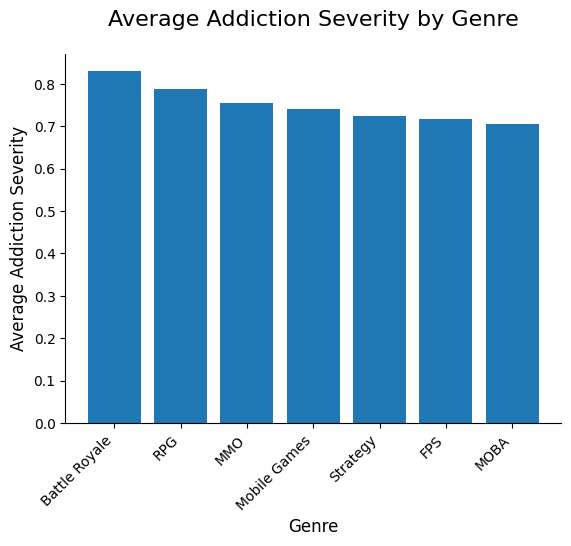

In [185]:
# Bar Chart
plt.bar(genre_addiction.index, genre_addiction.values)

plt.title("Average Addiction Severity by Genre", fontsize=16, pad=20)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Average Addiction Severity", fontsize=12)

plt.xticks(rotation=45, ha='right')
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout
plt.show()



C:\Users\jlax\AppData\Local\Temp\ipykernel_27096\533036390.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y='addiction_severity', palette=my_colors)
C:\Users\jlax\AppData\Local\Temp\ipykernel_27096\533036390.py:6: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.boxplot(data=df, x='genre', y='addiction_severity', palette=my_colors)


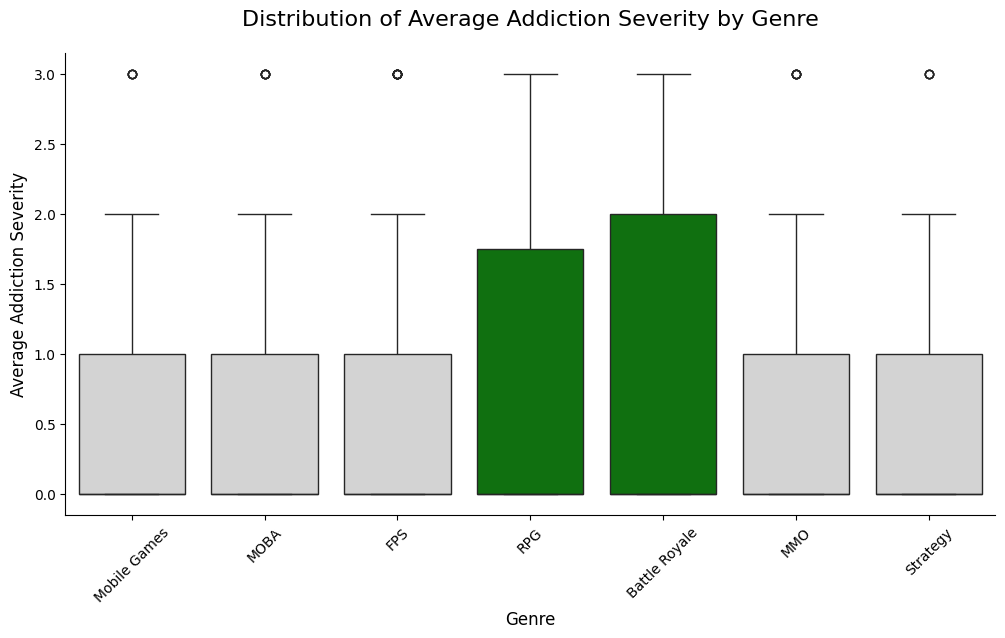

In [186]:
# Box Plot
plt.figure(figsize=(12, 6))

my_colors = ["lightgray", "lightgray", "lightgray", "green", "green", "lightgray", "lightgray", "lightgray"]

sns.boxplot(data=df, x='genre', y='addiction_severity', palette=my_colors)

plt.title("Distribution of Average Addiction Severity by Genre", fontsize=16, pad=20)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Average Addiction Severity", fontsize=12)
plt.xticks(rotation=45)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


With the bar chart and the box plot I have learned that while on the whole, genre doesn't necessarily affect addiction level, the box plot reveals that RPGs and Battle Royale type games yield a wider distribution of a higher addiction level than other genres, which are relatively the same. I want to do some deeper analysis between these two genres to see why they might have higher addiction levels.

In [187]:
#Comparing daily hours of play according to genre
hours_per_genre = df.groupby("genre")["daily_gaming_hours"].mean().sort_values(ascending=False)
hours_per_genre

genre
Strategy         6.366667
Battle Royale    6.304965
Mobile Games     6.233094
MMO              6.222378
RPG              6.130137
MOBA             5.962179
FPS              5.846269
Name: daily_gaming_hours, dtype: float64

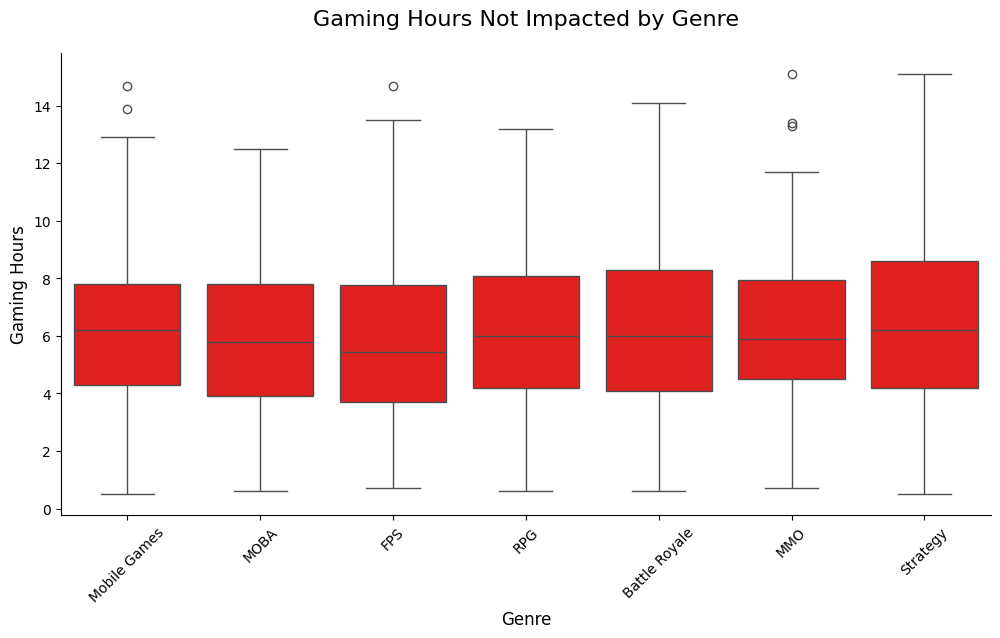

In [188]:
#Box Plot
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='genre', y='daily_gaming_hours', color='red')

plt.title("Gaming Hours Not Impacted by Genre", fontsize=16, pad=20)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Gaming Hours", fontsize=12)
plt.xticks(rotation=45)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

After comparing the amount of time that players play according to the genre, it doesn't seem to be a huge difference in play time. This suggests that sheer amount of time played is not the only factor affecting addiction severity. Next, I will see if monthly spending by genre makes the difference for addiction severity.

In [189]:
#Comparing amount of monthly spending by genre
spend_per_genre = df.groupby("genre")["monthly_spend"].mean().sort_values(ascending=False)
spend_per_genre

genre
Strategy         115.164894
MMO              114.467063
MOBA             109.110833
RPG              106.900822
Battle Royale     98.160284
Mobile Games      97.720288
FPS               93.732537
Name: monthly_spend, dtype: float64

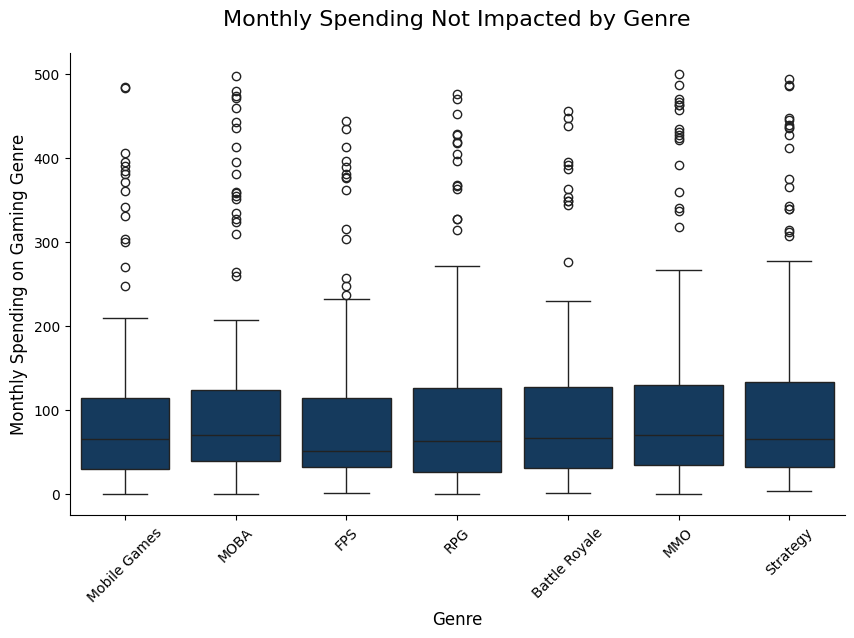

In [190]:
#Box Plot
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='genre', y='monthly_spend', color="#093b69")

plt.title("Monthly Spending Not Impacted by Genre", fontsize=16, pad=20)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Monthly Spending on Gaming Genre", fontsize=12)
plt.xticks(rotation=45)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

While there are many outliers in the monthly spending, they are present across each genre. The averages are remarkably consistent, just as time spent and genre don't affect the addiction score. This suggests that something more qualitative may contribute to the addiction severity. I can count questions 1 and 5 as answered at this point. Genre does have some difference in addiction severity between Battle Royale and RPG, but the cause is yet to be discovered.

In [191]:
# 2. How does addiction score correlate with physical health? (Comparing numbers)


Text(0.5, 1.0, 'Number of Patients per Category')

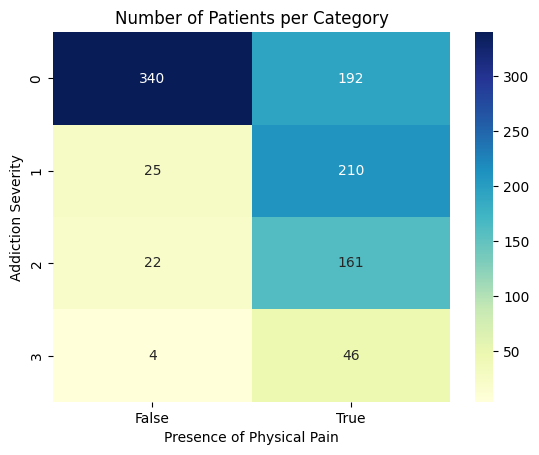

In [192]:
#Heat Map
counts = df.groupby(['addiction_severity', 'physical_pain']).size().unstack(fill_value=0)

sns.heatmap(counts, annot=True, fmt="d", cmap="YlGnBu")

plt.ylabel("Addiction Severity")
plt.xlabel("Presence of Physical Pain")
plt.title("Number of Patients per Category")


Text(0.5, 1.0, 'Higher Percentage of Physical Pain Correlated to Addiction Severity')

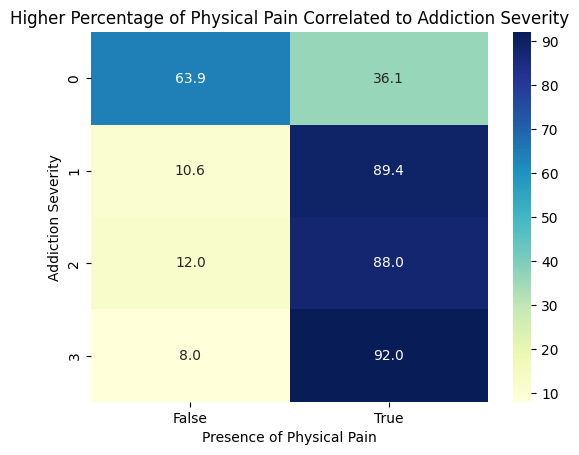

In [193]:
pct_table = pd.crosstab(df['addiction_severity'],
                        df['physical_pain'],
                        normalize='index') * 100

sns.heatmap(pct_table, annot=True, fmt=".1f", cmap="YlGnBu")

plt.ylabel("Addiction Severity")
plt.xlabel("Presence of Physical Pain")
plt.title("Higher Percentage of Physical Pain Correlated to Addiction Severity")


This heat map suggests a positive correlation between higher addiction severity scores with the presence of physical pain. The first heatmap shows that more people report physical pain with lower severity scores. However, this is because there is a larger number of people with a lower addiction severity. However, as seen by the second heatmap, the percentage of people who report physical pain with a higher severity score is much higher. This suggests a positive correlation between higher addiction levels and physical pain. Next, just to get a bit more detailed, heat maps will be generated with the specific kind of physical pain.

Text(0.5, 1.0, 'Eye Strain Present Regardless of Addiction Severity')

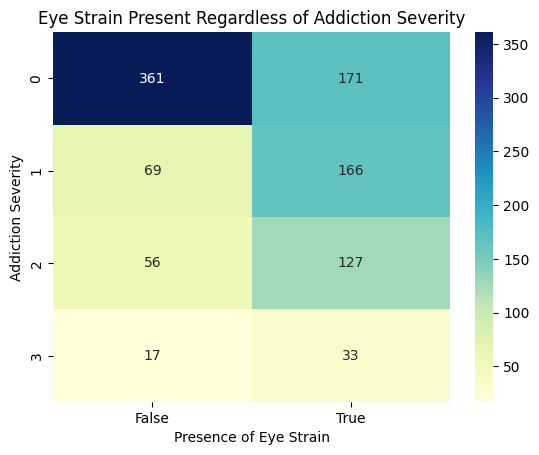

In [194]:
counts = df.groupby(['addiction_severity', 'eye_strain']).size().unstack(fill_value=0)

sns.heatmap(counts, annot=True, fmt="d", cmap="YlGnBu")

plt.ylabel("Addiction Severity")
plt.xlabel("Presence of Eye Strain")
plt.title("Eye Strain Present Regardless of Addiction Severity")

Text(0.5, 1.0, 'Number of Patients per Category')

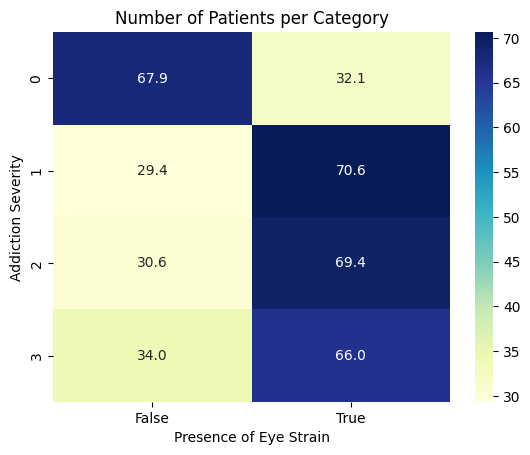

In [195]:
pct_table = pd.crosstab(df['addiction_severity'],
                        df['eye_strain'],
                        normalize='index') * 100

sns.heatmap(pct_table, annot=True, fmt=".1f", cmap="YlGnBu")

plt.ylabel("Addiction Severity")
plt.xlabel("Presence of Eye Strain")
plt.title("Number of Patients per Category")

Text(0.5, 1.0, 'Number of Patients per Category')

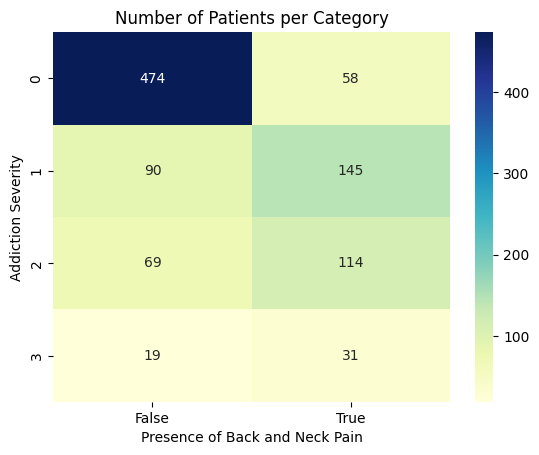

In [196]:
counts = df.groupby(['addiction_severity', 'back_neck_pain']).size().unstack(fill_value=0)

sns.heatmap(counts, annot=True, fmt="d", cmap="YlGnBu")

plt.ylabel("Addiction Severity")
plt.xlabel("Presence of Back and Neck Pain")
plt.title("Number of Patients per Category")

Text(0.5, 1.0, 'Number of Patients per Category')

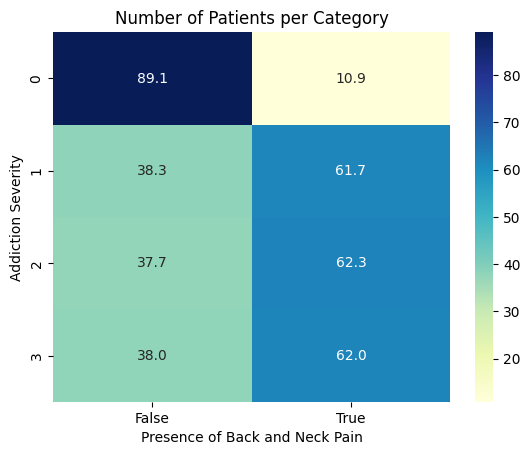

In [197]:
pct_table = pd.crosstab(df['addiction_severity'],
                        df['back_neck_pain'],
                        normalize='index') * 100

sns.heatmap(pct_table, annot=True, fmt=".1f", cmap="YlGnBu")

plt.ylabel("Addiction Severity")
plt.xlabel("Presence of Back and Neck Pain")
plt.title("Number of Patients per Category")

First, a comparison between the two heat maps by count of eye strain and back and neck pain yield an interesting discrepancy. The presence of eyestrain is consistent with the greater number of people that have a low addiction severity score, but the presence of back and neck pain is low until the addiction severity increases to 1. This suggests that eye strain may be present to some degree for any level of gaming addiction. This corresponds with the idea that screens impact eye health. However, back and neck pain is more specific to higher levels of addiction. This makes sense since gaming for longer periods of time entails being sedentary, which corresponds to greater back and neck pain and stiffness. The percentages, however, for both stypes of pain, general match the overall physical pain score. The correlation between the presence of physical pain and higher levels of gaming addiction is thus vindicated. 

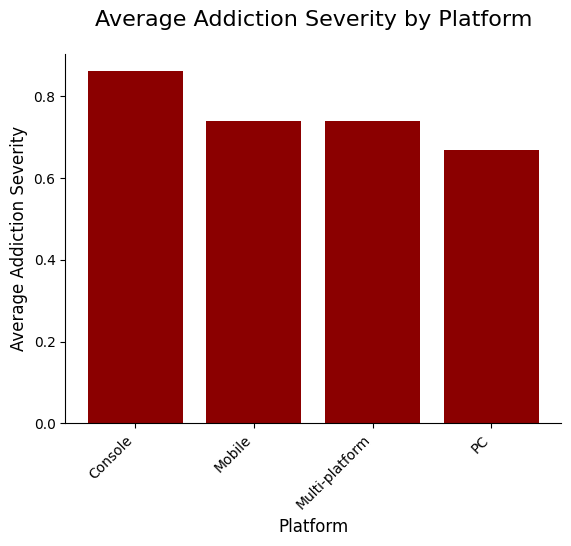

In [198]:
# 3. Which platform had the highest addiction score? (Comparing categories)
#Bar Chart
addiction_by_platform = df.groupby('gaming_platform')['addiction_severity'].mean().sort_values(ascending=False)

plt.bar(addiction_by_platform.index, addiction_by_platform.values, color = 'darkred')

plt.title("Average Addiction Severity by Platform", fontsize=16, pad=20)
plt.xlabel("Platform", fontsize=12)
plt.ylabel("Average Addiction Severity", fontsize=12)

plt.xticks(rotation=45, ha='right')
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout
plt.show()



C:\Users\jlax\AppData\Local\Temp\ipykernel_27096\2172392449.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gaming_platform', y='addiction_severity', palette=colors)


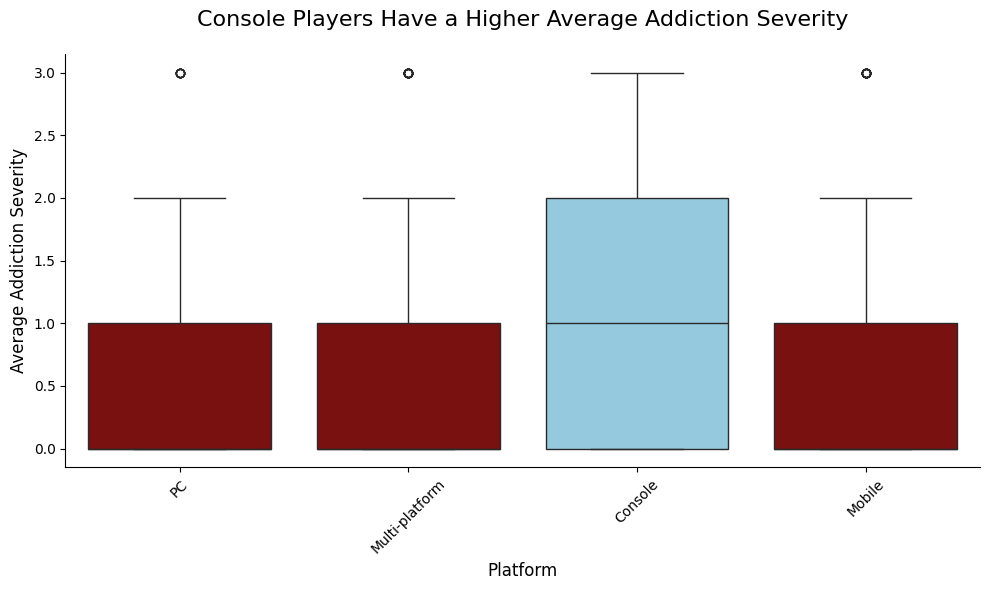

In [199]:
#Box Plot
plt.figure(figsize=(10, 6))

colors = ['darkred', 'darkred', 'skyblue', 'darkred']
sns.boxplot(data=df, x='gaming_platform', y='addiction_severity', palette=colors)

plt.title("Console Players Have a Higher Average Addiction Severity", fontsize=16, pad=20)
plt.xlabel("Platform", fontsize=12)
plt.ylabel("Average Addiction Severity", fontsize=12)
plt.xticks(rotation=45)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

This box plots suggest a correlation between higher addiction severity and playing on a console. However, it's possible that there could just be more console players surveyed. To see further if there is a correlation, a count plot will be made.

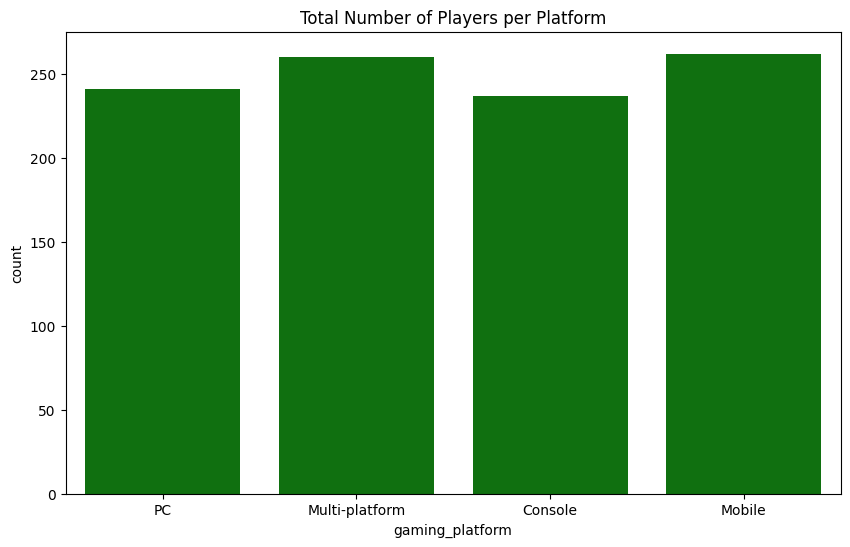

In [200]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='gaming_platform', color='green')
plt.title("Total Number of Players per Platform")
plt.show()

Since the amount of players per platform is relatively stable, this suggest the correlation between addiction severity and console gaming stands. Next, an analysis of which games in the list of console games are most addictive.

C:\Users\jlax\AppData\Local\Temp\ipykernel_27096\156367448.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=console_focus, x='genre', y='addiction_severity', palette=colors)
C:\Users\jlax\AppData\Local\Temp\ipykernel_27096\156367448.py:12: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=console_focus, x='genre', y='addiction_severity', palette=colors)


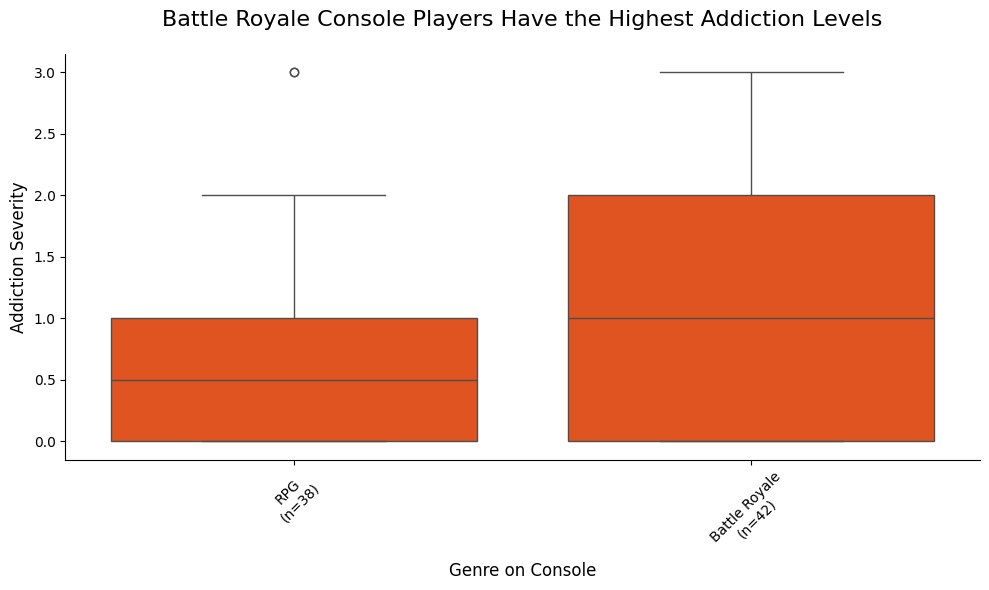

In [201]:
#Box Plot
target_genres = ['Battle Royale', 'RPG']
console_focus = df[(df['gaming_platform'] == 'Console') &
                   (df['genre'].isin(target_genres))]

rpg_num = len(console_focus[console_focus['genre'] == 'RPG'])
br_num = len(console_focus[console_focus['genre'] == 'Battle Royale'])

plt.figure(figsize=(10, 6))

colors = ['orangered']
sns.boxplot(data=console_focus, x='genre', y='addiction_severity', palette=colors)

plt.xticks([0, 1], [f'RPG\n(n={rpg_num})', f'Battle Royale\n(n={br_num})'], rotation=0)

plt.title("Battle Royale Console Players Have the Highest Addiction Levels", fontsize=16, pad=20)
plt.xlabel("Genre on Console", fontsize=12)
plt.ylabel("Addiction Severity", fontsize=12)
plt.xticks(rotation=45)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

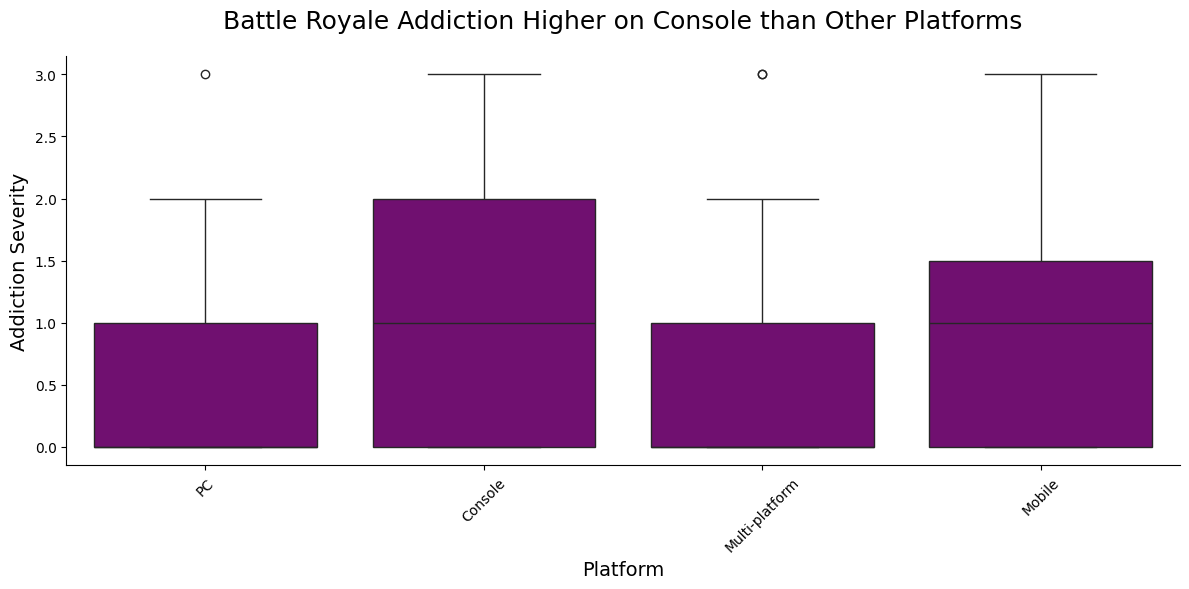

In [202]:
br_all_platforms = df[df['genre'] == 'Battle Royale']

plt.figure(figsize=(12, 6))
sns.boxplot(data=br_all_platforms, x='gaming_platform', y='addiction_severity', color = 'purple')

plt.title("Battle Royale Addiction Higher on Console than Other Platforms", fontsize=18,pad=20)
plt.xlabel("Platform", fontsize=14)
plt.ylabel("Addiction Severity", fontsize=14)
plt.xticks(rotation=45)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

These findings correspond to those of Question 1, where it was determined that RPGs and Battle Royale games have the highest levels of addiction severity. Specifically, one can now see that Battle Royale players on console have the highest rates of addiction. This suggests that something about playing both Battle Royale games and on a console leads to higher rates of gaming addiction. Even when one compares Battle Royale players across different platforms, console still yields a higher addiction severity.

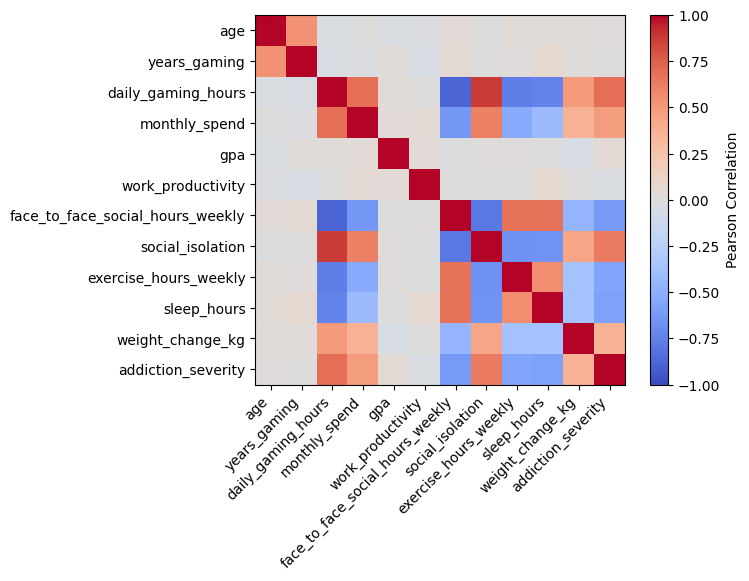

In [203]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, label='Pearson Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

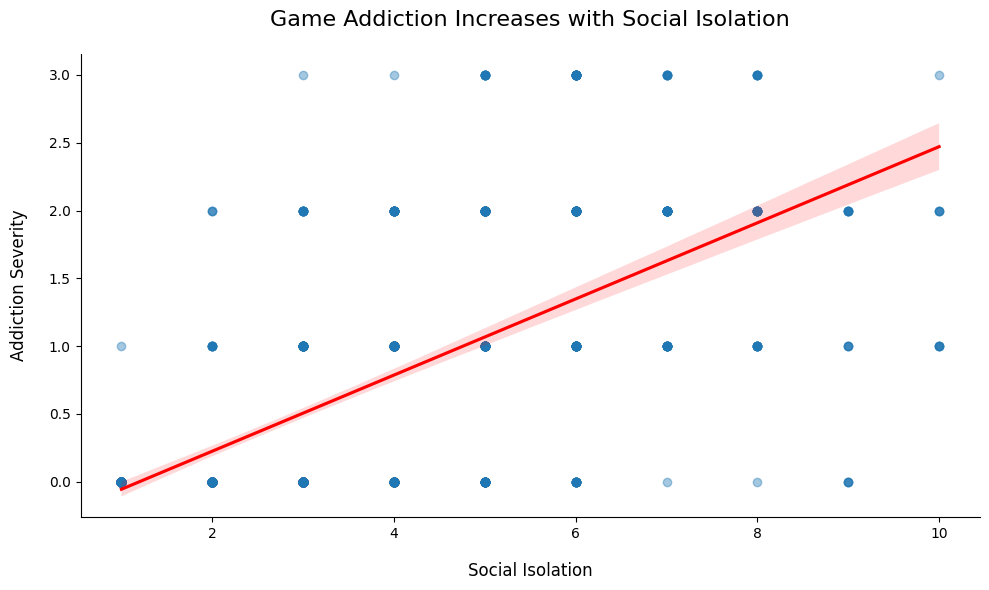

In [204]:
# 4. How does social isolation correlate with negative outcomes? (Visualizing relationships)

plt.figure(figsize=(10,6))
sns.regplot(x='social_isolation',
            y='addiction_severity',
            data=df,
            scatter_kws={'alpha':0.4},
            line_kws={'color':'red'})

plt.title("Game Addiction Increases with Social Isolation", fontsize=16, pad=20)
plt.xlabel("Social Isolation", fontsize=12, labelpad=15)
plt.ylabel("Addiction Severity", fontsize=12, labelpad=15)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

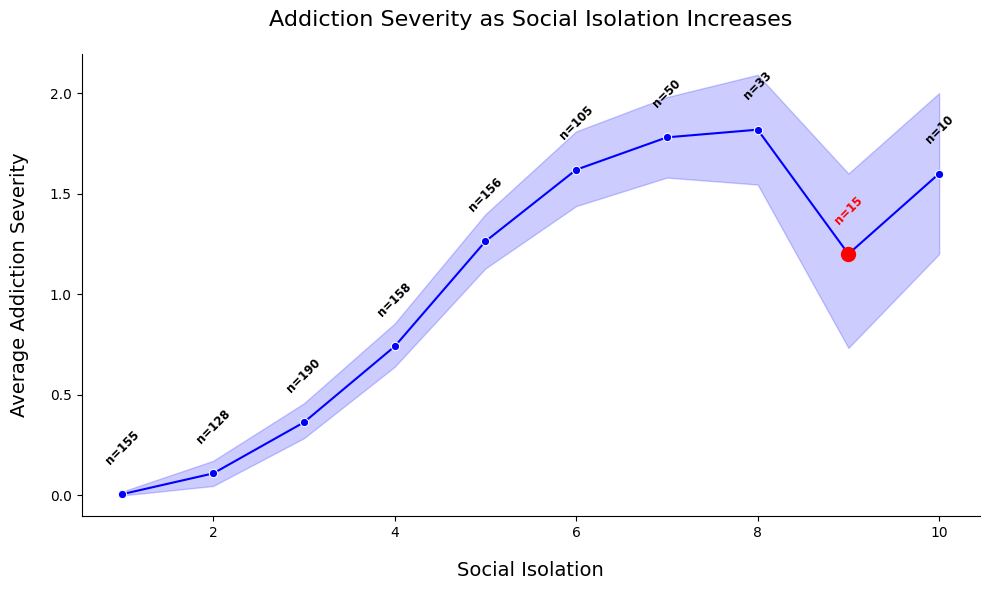

In [205]:
plt.figure(figsize=(10,6))
sns.lineplot(x='social_isolation', y='addiction_severity', data=df, marker='o', color='blue')

counts = df['social_isolation'].value_counts().sort_index()
averages = df.groupby('social_isolation')['addiction_severity'].mean()

plt.scatter(9, averages[9], color='red', s=100, zorder=5, label='n=15 (Low Sample Size)')

for x, y in averages.items():
    text_color = 'red' if x == 9 else 'black'
    plt.text(x, y + 0.15, f'n={counts[x]}',
             horizontalalignment='center',
             size='small',
             color=text_color, 
             weight='semibold',
             rotation=45)

plt.title("Addiction Severity as Social Isolation Increases", fontsize=16, pad=20)
plt.xlabel("Social Isolation", fontsize=14, labelpad=15)
plt.ylabel("Average Addiction Severity", fontsize=14, labelpad=15)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [206]:
print(df['social_isolation'].value_counts().sort_index())

social_isolation
1     155
2     128
3     190
4     158
5     156
6     105
7      50
8      33
9      15
10     10
Name: count, dtype: int64


These two graphs show clearly that social isolation and addiction severity are correlated to each other. The variance at addiction severity level 9 is due to the low sample size, as seen on the plot above. However, the overall trend is correlation. This does not explain whether addiction severity causes social isolation or vice versa.

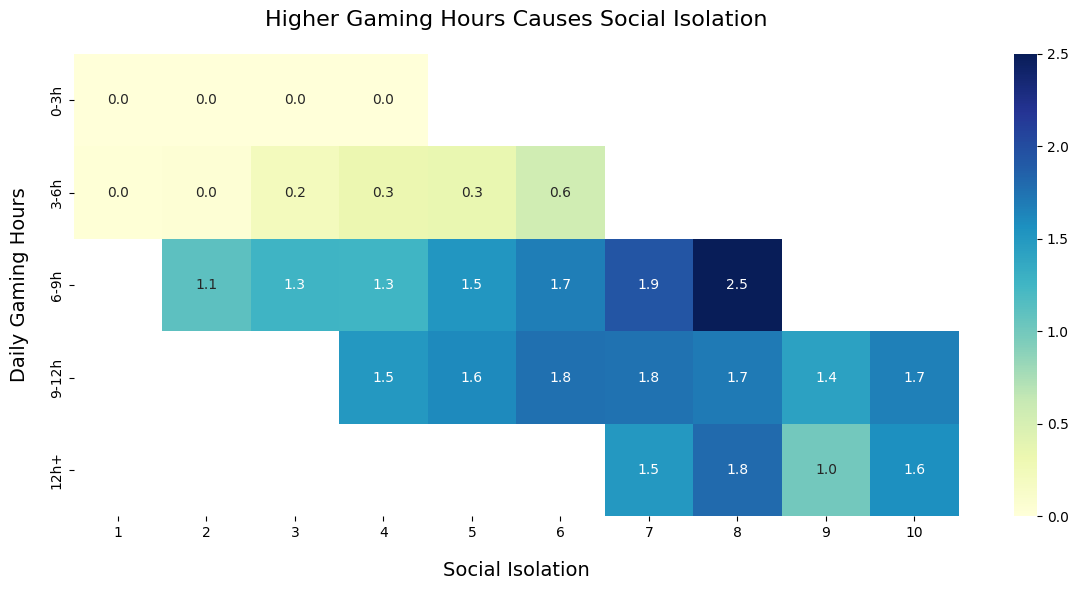

In [207]:
# Attempt to show the causation for this correlation
hours = ['0-3h', '3-6h', '6-9h', '9-12h', '12h+']

df['hours_bin'] = pd.cut(df['daily_gaming_hours'], bins=5, labels=hours)
pivot = df.pivot_table(index='hours_bin', columns='social_isolation', values='addiction_severity', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".1f")

plt.title("Higher Gaming Hours Causes Social Isolation", fontsize=16, pad=20)
plt.xlabel("Social Isolation", fontsize=14, labelpad=15)
plt.ylabel("Daily Gaming Hours", fontsize=14, labelpad=15)

plt.tight_layout()
plt.show()

In [208]:
df['daily_gaming_hours'].corr(df['social_isolation'])

np.float64(0.8760703641655155)

This heat map shows the direct correlation between social isolation and the number of hours somebody games. Addiction severity seems to be exacerbated by the social isolation, which is then reinforced by even more hours gaming.

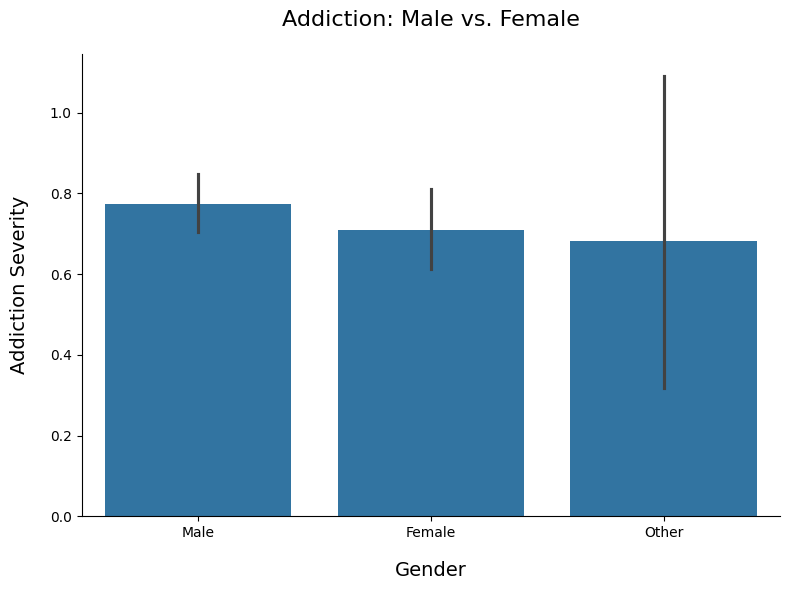

In [209]:
# 6. Does gender affect how addicted one might be? (Comparing categories)
plt.figure(figsize=(8,6))
sns.barplot(x='gender', y='addiction_severity', data=df)
plt.title("Addiction: Male vs. Female", fontsize=16, pad=20)
plt.xlabel("Gender", fontsize=14, labelpad=15)
plt.ylabel("Addiction Severity", fontsize=14, labelpad=15)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

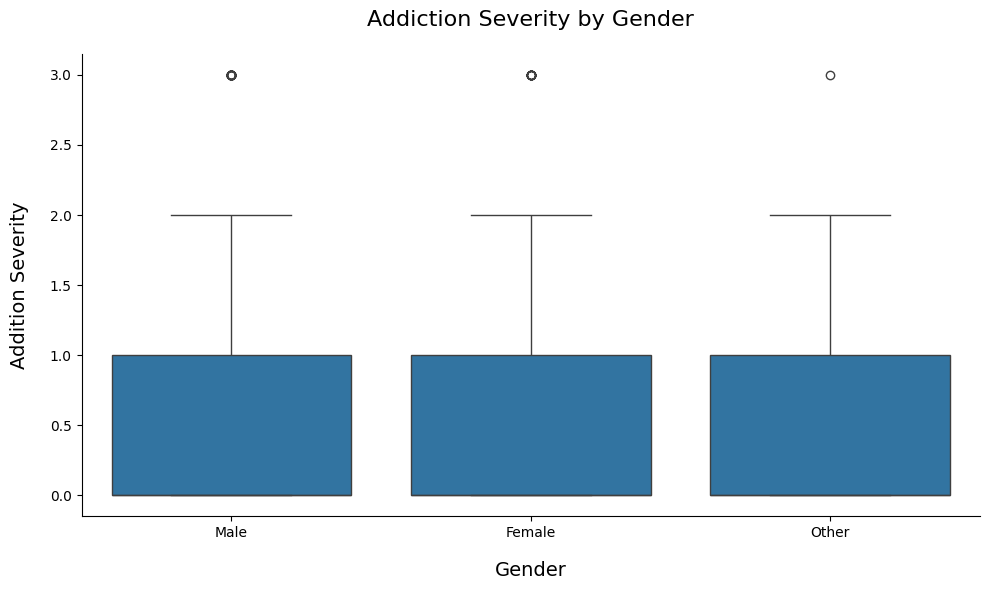

In [210]:
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='addiction_severity', data=df)
plt.title("Addiction Severity by Gender", fontsize=16, pad=20)
plt.xlabel("Gender", fontsize=14, labelpad=15)
plt.ylabel("Addition Severity", fontsize=14, labelpad=15)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

These plots show that gender has no impact on gaming addiction severity. There is no significant statistical difference between all genders. 

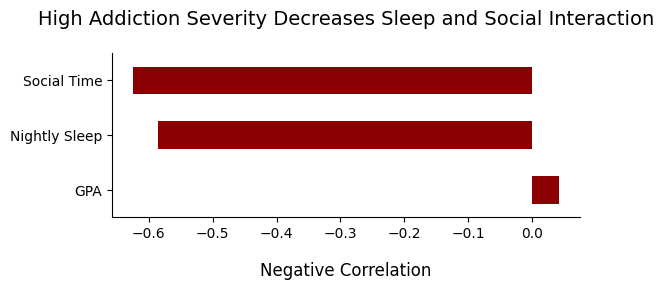

In [211]:
# 7. Which life factor (GPA, Sleep, or Social) has the strongest negative correlation with the addiction score? (Comparing numbers)
factors = ['gpa', 'sleep_hours', 'face_to_face_social_hours_weekly']
correlations = df[factors].corrwith(df['addiction_severity'])

clean_labels = {
    'gpa': 'GPA',
    'sleep_hours': 'Nightly Sleep',
    'face_to_face_social_hours_weekly': 'Social Time'
}
correlations = correlations.rename(index=clean_labels)

ax = correlations.plot(kind='barh', color='darkred', figsize=(6,3))
plt.title("High Addiction Severity Decreases Sleep and Social Interaction", fontsize=14, pad=20)
plt.xlabel("Negative Correlation", fontsize=12, labelpad=15)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

While GPA doesn't seem to be too negatively affected by high gaming addiction levels, social interaction and the amount of sleep one receives goes down significantly. This is to be expected, as the time spent on gaming would replace the time spent interacting with others and sleeping. GPA seems to not be as affected most likely because it is seen as a more non-negotiable priority.

Conclusion: Based on the visualizations regarding addiction severity, we can conclude the following:
1. RPGs and Battle Royale game genres have higher rates of addiction than other genres.
2. Total play time does not neatly correlate to higher levels of gaming addiction.
3. Monthly spending does not vary much between genres.
4. Higher rates of addiction severity correlate to higher rates of physical pain from gaming.
5. Not only do Battle Royale and RPG genres have higher rates of addiction, but the severity is higher on consoles vs. other gaming platforms.
6. Gender, despite many stereotypes, does not impact addiction severity levels.
7. Social isolation and higher rates of gaming addiction are strongly correlated. While it's not clear which causes the other, it is likely a combination of both, with social isolation increasing along with gaming addiction, and the two creating a feedback loop that reinforces the other. In other words, being addicted to games may lead to greater social isolation, which then leads to greater gaming addiction. This holds even if social isolation happens first.

## Capstone Project

In order to continue delving into addiction severity according to console platform and gaming genre, I am importing several csvs from the data set found on Kaggle called Gaming Profiles 2025. It has data for Playstation, XBox, and Steam. This will be combined with the current data I already have regarding Gaming and Mental Health.

In [212]:
#This is a function created to load all the csv's at once and rename columns.

def read_platform_data(platform_name, base_path=r'../Gaming_Profiles_Data'):
    players_df = pd.read_csv(f'{base_path}/{platform_name}/players.csv')
    purchased_df = pd.read_csv(f'{base_path}/{platform_name}/purchased_games.csv')
    games_df = pd.read_csv(f'{base_path}/{platform_name}/games.csv')
    players_df = players_df.rename(columns={'playerid': 'player_id', 'gameid': 'game_id'})
    purchased_df = purchased_df.rename(columns={'playerid': 'player_id', 'gameid': 'game_id'})
    games_df = games_df.rename(columns={'playerid': 'player_id', 'gameid': 'game_id'})

    return players_df, purchased_df, games_df

steam_players, steam_purchased, steam_games = read_platform_data('steam')
ps_players, ps_purchased, ps_games = read_platform_data('playstation')
xbox_players, xbox_purchased, xbox_games = read_platform_data('xbox')


In [213]:
#This is a loop created to check to ensure that the column names have been renamed successfully.
platform_dfs = {
    'Steam Players': steam_players,
    'Steam Purchased': steam_purchased,
    'Steam Games': steam_games,
    'PS Players': ps_players,
    'PS Purchased': ps_purchased,
    'PS Games': ps_games,
    'Xbox Players': xbox_players,
    'Xbox Purchased': xbox_purchased,
    'Xbox Games': xbox_games
}

for name, platform_df in platform_dfs.items():
    print(name, df.columns)

Steam Players Index(['record_id', 'age', 'gender', 'occupation', 'years_gaming',
       'daily_gaming_hours', 'genre', 'primary_game', 'gaming_platform',
       'monthly_spend', 'academic_performance', 'gpa', 'work_productivity',
       'face_to_face_social_hours_weekly', 'social_isolation',
       'exercise_hours_weekly', 'sleep_hours', 'sleep_quality',
       'sleep_disruption', 'eye_strain', 'back_neck_pain', 'physical_pain',
       'weight_change_kg', 'mood_state', 'mood_swings', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems',
       'gaming_addiction_risk_level', 'addiction_severity', 'hours_bin'],
      dtype='str')
Steam Purchased Index(['record_id', 'age', 'gender', 'occupation', 'years_gaming',
       'daily_gaming_hours', 'genre', 'primary_game', 'gaming_platform',
       'monthly_spend', 'academic_performance', 'gpa', 'work_productivity',
       'face_to_face_social_hours_weekly', 'social_isolation',
       'exercise_hours_weekly', 'sle

Next, I am going to merge the dataframes together according to platform using some advice and guidance from Gemini AI. First, I will need to link the platform game lists together.

In [214]:
#Platform Game Link
steam_games['platform'] = 'Steam'
ps_games['platform'] = 'Playstation'
xbox_games['platform'] = 'Xbox'

master_games = pd.concat([steam_games, ps_games, xbox_games], ignore_index=True)

In [215]:
#Clean up the survey column titles
df['primary_game'] = df['primary_game'].astype(str).str.strip().str.lower()

#Clean up the master catalog titles I created
master_games['title'] = master_games['title'].astype(str).str.strip().str.lower()

In [216]:
#Merge the two data frames, df and master_games, together
df_master = pd.merge(
    df,
    master_games[['title', 'game_id']],
    left_on='primary_game',
    right_on='title',
    how='left'
)

df_master.head()

,record_id,age,gender,occupation,years_gaming,daily_gaming_hours,genre,primary_game,gaming_platform,monthly_spend,...,mood_state,mood_swings,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,gaming_addiction_risk_level,addiction_severity,hours_bin,title,game_id
0,GD0001,17,Male,Student,3,11.1,Mobile Games,clash of clans,PC,383.70,...,Anxious,Never,True,False,True,Severe,2,9-12h,NaN,NaN
1,GD0002,21,Male,Student,1,3.0,MOBA,dota 2,PC,46.64,...,Irritable,Often,False,False,False,Low,0,0-3h,dota 2,570.0
2,GD0003,23,Male,Professional,6,7.6,FPS,cs:go,Multi-platform,100.81,...,Irritable,Rarely,True,True,True,Severe,3,6-9h,NaN,NaN
3,GD0004,20,Female,Student,7,7.2,RPG,skyrim,Multi-platform,51.60,...,Withdrawn,Daily,True,True,False,High,2,6-9h,skyrim,2435.0
4,GD0005,18,Male,Student,1,6.8,Battle Royale,apex legends,PC,32.57,...,Angry,Daily,True,False,False,Moderate,1,6-9h,apex legends,176538.0


In [217]:
#Isolate the NaN values that didn't match games
unmatched_games = df_master[df_master['game_id'].isnull()]['primary_game'].value_counts()

print(unmatched_games.head(15))

primary_game
starcraft ii            55
world of warcraft       52
civilization vi         51
mobile legends          50
league of legends       49
final fantasy xiv       47
elder scrolls online    44
clash of clans          39
cs:go                   36
pubg mobile             36
call of duty            35
pubg                    35
age of empires          35
overwatch               30
candy crush             28
Name: count, dtype: int64


In [218]:
#Used AI-generated code to be able to find the titles of certain games so that they match between datasets
print("1. WoW Match:", master_games[master_games['title'].str.contains('warcraft', na=False)]['title'].unique())
print("2. Civ Match:", master_games[master_games['title'].str.contains('civilization', na=False)]['title'].unique())
print("3. StarCraft Match:", master_games[master_games['title'].str.contains('starcraft', na=False)]['title'].unique())
print("4. League Match:", master_games[master_games['title'].str.contains('league', na=False)]['title'].unique())
print("5. Final Fantasy Match:", master_games[master_games['title'].str.contains('final fantasy xiv', na=False)]['title'].unique())

1. WoW Match: <StringArray>
['prehistoric warcraft', '守卫魔兽-guardian of warcraft']
Length: 2, dtype: str
2. Civ Match: <StringArray>
[                                               'vr historical journey to the buddhist civilizations: vr ancient india and asia',
 'vr time machine travelling in ancient civilizations: mayan kingdom, inca empire, indians, and aztecs before conquest a.d.1000',
                                                                                                               '4 civilizations',
                                                                                                         'girls' civilization 2',
                                                                                                 'kainga: seeds of civilization',
                                                                                                             'microcivilization',
                                                                                        

In [219]:
# Create a targeted mapping dictionary for your top mismatched titles
game_translation_map = {
    'civilization vi': "sid meier's civilization vi",
    'final fantasy xiv': 'final fantasy xiv online',
    'cs:go': 'counter-strike: global offensive'
}

# Apply the translation directly to your clean primary game column in the survey
df['primary_game'] = df['primary_game'].replace(game_translation_map)


In [220]:
#The following are either Non-Steam PC games or are mobile games not included in the additional Gaming Profile 2025 csv's. They will be N/A.
#primary_game
#starcraft ii            55
#world of warcraft       52
#mobile legends          50
#league of legends       49
#elder scrolls online    44
#clash of clans          39
#pubg mobile             36
#call of duty            35
#pubg                    35
#age of empires          35
#overwatch               30
#candy crush             28
#Name: count, dtype: int64

In [221]:
#Fill NaN with N/A
df_master['game_id'] = df_master['game_id'].fillna('N/A')

print(df_master['game_id'].isnull().sum())

0


In [222]:
#Make the csv's to use for the tables to be used in the relational database.
def create_relational_database(df_survey, df_catalog):
    path = '../Gaming_Profiles_Data/processed_tables/'
    df_survey.to_csv(path + 'survey_responses.csv', index=False)
    df_catalog[['game_id', 'title', 'developers', 'publishers']].drop_duplicates(subset=['game_id']).to_csv(path + 'games_catalog.csv', index=False)
    df_catalog[['game_id', 'platform']].drop_duplicates().to_csv(path + 'game_platforms.csv', index=False)
    df_genres = df_catalog[['game_id', 'genres']].copy()
    df_genres['genres'] = df_genres['genres'].astype(str).str.split(',')
    df_genres = df_genres.explode('genres')
    df_genres['genres'] = df_genres['genres'].str.strip()
    df_genres['genres'] = df_genres['genres'].fillna('Unclassified')
    df_genres['genres'] = df_genres['genres'].str.replace('[', '', regex=False)
    df_genres['genres'] = df_genres['genres'].str.replace(']', '', regex=False)
    df_genres['genres'] = df_genres['genres'].str.replace("'", "", regex=False)
    df_genres.drop_duplicates().to_csv(path + 'game_genres.csv', index=False)

create_relational_database(df_master, master_games)

In [223]:
# Read the updated genres CSV file back into memory
path = '../Gaming_Profiles_Data/processed_tables/'
saved_genres_df = pd.read_csv(path + 'game_genres.csv')

# Look at the first 20 rows
print(saved_genres_df.head(20))


    game_id        genres
0   3281560  Unclassified
1   3280930  Unclassified
2   3280770  Unclassified
3   3279790  Unclassified
4   3278320  Unclassified
5   3278740        Action
6   3277430  Unclassified
7   3276500  Unclassified
8   3274370  Unclassified
9   3274670  Unclassified
10  3270850         Indie
11  3271040  Unclassified
12  3270450  Unclassified
13  3269910  Unclassified
14  3268170  Unclassified
15  3267350        Action
16  3267350  Free To Play
17  3266750  Unclassified
18  3266470     Adventure
19  3266470        Casual


In [224]:
#Creating ERD for the relational database

#Display columns names from CSV files
path = '../Gaming_Profiles_Data/processed_tables/'
{
     '1. survey_responses': pd.read_csv(path + 'survey_responses.csv').columns.tolist(),
    '2. games_catalog': pd.read_csv(path + 'games_catalog.csv').columns.tolist(),
    '3. game_platforms': pd.read_csv(path + 'game_platforms.csv').columns.tolist(),
    '4. game_genres': pd.read_csv(path + 'game_genres.csv').columns.tolist()
}

{'1. survey_responses': ['record_id',
  'age',
  'gender',
  'occupation',
  'years_gaming',
  'daily_gaming_hours',
  'genre',
  'primary_game',
  'gaming_platform',
  'monthly_spend',
  'academic_performance',
  'gpa',
  'work_productivity',
  'face_to_face_social_hours_weekly',
  'social_isolation',
  'exercise_hours_weekly',
  'sleep_hours',
  'sleep_quality',
  'sleep_disruption',
  'eye_strain',
  'back_neck_pain',
  'physical_pain',
  'weight_change_kg',
  'mood_state',
  'mood_swings',
  'withdrawal_symptoms',
  'loss_of_other_interests',
  'continued_despite_problems',
  'gaming_addiction_risk_level',
  'addiction_severity',
  'hours_bin',
  'title',
  'game_id'],
 '2. games_catalog': ['game_id', 'title', 'developers', 'publishers'],
 '3. game_platforms': ['game_id', 'platform'],
 '4. game_genres': ['game_id', 'genres']}

ERD

<img src="../images/gaming_mental_health_ERD.png" alt="Database ERD Schema" width="600"/>


In [226]:
#Create Database

# Step 1. Database Connection
connection = sqlite3.connect('../Gaming_Profiles_Data/processed_tables/gaming_mental_health.db')
cursor = connection.cursor()
cursor.execute("PRAGMA foreign_keys = ON;")
print("Database Created")

Database Created


In [228]:
# Step 2. Create Base Look Up Tables

# games_catalog
cursor.execute("""
CREATE TABLE IF NOT EXISTS games_catalog (
    game_id TEXT PRIMARY KEY,
    title TEXT,
    developers TEXT,
    publishers TEXT
);
""")

# gamer_dem
cursor.execute("""
CREATE TABLE IF NOT EXISTS gamer_dem (
    record_id INTEGER PRIMARY KEY,
    age INTEGER,
    gender TEXT,
    occupation TEXT
);
""")

# connection
connection.commit()
print("games_catalog and gamer_dem tables created")

games_catalog and gamer_dem tables created


In [229]:
# Step 3. Create Platforms and Genres Tables

# game_platforms
cursor.execute("""
CREATE TABLE IF NOT EXISTS game_platforms (
    game_id TEXT,
    platform TEXT,
    PRIMARY KEY (game_id, platform),
    FOREIGN KEY (game_id) REFERENCES games_catalog(game_id)
);
""")

# games_genres
cursor.execute("""
CREATE TABLE IF NOT EXISTS game_genres (
    game_id TEXT,
    genres TEXT,
    PRIMARY KEY (game_id, genres),
    FOREIGN KEY (game_id) REFERENCES games_catalog(game_id)
);
""")

# connection
connection.commit()
print("game_platforms and game_genres tables created")

game_platforms and game_genres tables created


In [232]:
# Step 4. Create the Survey Facts Table

# survey_responses
cursor.execute("""
CREATE TABLE IF NOT EXISTS survey_responses (
    response_id INTEGER PRIMARY KEY AUTOINCREMENT,
    record_id INTEGER,
    game_id TEXT,
    years_gaming INTEGER,
    daily_gaming_hours REAL,
    monthly_spend REAL,
    academic_performance TEXT,
    gpa REAL,
    work_productivity INTEGER,
    face_to_face_social_hours_weekly REAL,
    social_isolation INTEGER,
    exercise_hours_weekly REAL,
    sleep_hours REAL,
    sleep_quality TEXT,
    sleep_disruption TEXT,
    eye_strain INTEGER,
    back_neck_pain INTEGER,
    physical_pain INTEGER,
    weight_change_kg REAL,
    mood_state TEXT,
    mood_swings TEXT,
    withdrawal_symptoms INTEGER,
    loss_of_other_interests INTEGER,
    continued_despite_problems INTEGER,
    gaming_addiction_risk_level TEXT,
    addiction_severity INTEGER,
    hours_bin TEXT,
    FOREIGN KEY (record_id) REFERENCES gamer_dem(record_id),
    FOREIGN KEY (game_id) REFERENCES games_catalog(game_id)
);
""")

# connection
connection.commit()
print("survey_responses table created")

survey_responses table created
